# Reconocimiento Facial con Eigenfaces + Backpropagation

Pipeline completo:
- **Fase 1** — Detección y recorte de caras (MTCNN)
- **Fase 2** — Reducción de dimensionalidad (PCA / Eigenfaces)
- **Fase 3** — Visualización científica
- **Fase 4** — Entrenamiento con Backpropagation multiclase
- **Fase 5** — Agregar una persona nueva al dataset
- **Fase 6** — Predicción en fotos nuevas

# Nueva sección

In [2]:
from google.colab import drive
drive.mount('/content/drive')

fotos_originales = '/content/drive/MyDrive/02 - 2026 - Data Mining Avanzado/Caras'
fotos_finales    = '/content/drive/MyDrive/02 - 2026 - Data Mining Avanzado/Caras_2'
ruta_modelos     = '/content/drive/MyDrive/02 - 2026 - Data Mining Avanzado/Modelos'

Mounted at /content/drive


## Fase 1: Pre-procesamiento y Detección

Usaremos MTCNN para recortar y redimensionar cada cara a $64 \times 64$ en escala de grises.
¿Por qué grises? El color suele ser ruido para PCA; nos interesan las sombras y estructuras óseas.

In [3]:
!pip install mtcnn pillow_heif --quiet
!pip install itables --quiet

import os, cv2, numpy as np, math, time, pickle
import matplotlib.pyplot as plt
from PIL import Image
from mtcnn import MTCNN
from tqdm import tqdm
from pillow_heif import register_heif_opener
from IPython import display
from functools import reduce
import polars as pl
import joblib
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

register_heif_opener()
detector = MTCNN()
img_size = 64

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.0 MB/s eta 0:00:00


In [4]:
def _recortar_cara_con_margen(img_arr, box):
    """Recorte con margen del 20% — función compartida por todo el pipeline."""
    x, y, w, h = box
    margen = int(0.2 * min(w, h))
    x1 = max(0, x - margen)
    y1 = max(0, y - margen)
    x2 = min(img_arr.shape[1], x + w + margen)
    y2 = min(img_arr.shape[0], y + h + margen)
    return img_arr[y1:y2, x1:x2]


def procesar_dataset(origen, destino):
    os.makedirs(destino, exist_ok=True)
    for person in os.listdir(origen):
        path_p = os.path.join(origen, person)
        if not os.path.isdir(path_p) or person.startswith('.'): continue
        save_p = os.path.join(destino, person)
        os.makedirs(save_p, exist_ok=True)
        for img_name in tqdm(os.listdir(path_p), desc=f"Procesando {person}"):
            try:
                img = Image.open(os.path.join(path_p, img_name)).convert('RGB')
                img_arr = np.array(img)
                res = detector.detect_faces(img_arr)
                if res:
                    face         = _recortar_cara_con_margen(img_arr, res[0]['box'])
                    face_gray    = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)
                    face_resized = cv2.resize(face_gray, (img_size, img_size))
                    cv2.imwrite(os.path.join(save_p, img_name + ".jpg"), face_resized)
            except Exception as e:
                print(f"  ⚠️ Saltando {img_name}: {e}")

#procesar_dataset(fotos_originales, fotos_finales)

## Fase 2: PCA y Eigenfaces

Cada cara de $64 \times 64$ es un punto en un espacio de **4096 dimensiones**.
El PCA encuentra los ejes de mayor variación — las **Eigenfaces** — y reduce
esas 4096 dimensiones a solo ~150 números sin perder información relevante.

In [5]:
X          = []
all_labels = []
all_paths  = []
omitidas   = []

print("Cargando base de datos de rostros...")
for person in sorted(os.listdir(fotos_finales)):
    p_path = os.path.join(fotos_finales, person)
    if not os.path.isdir(p_path): continue
    for img_n in os.listdir(p_path):
        full_path = os.path.join(p_path, img_n)
        img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            omitidas.append(full_path)
            continue
        if img.shape != (img_size, img_size):
            img = cv2.resize(img, (img_size, img_size))
        X.append(img.flatten())
        all_labels.append(person)
        all_paths.append(full_path)

if omitidas:
    print(f"⚠ {len(omitidas)} archivos no se pudieron leer.")

X          = np.array(X) / 255.0
all_labels = np.array(all_labels)
print(f"\n✅ {len(X)} fotos de {len(np.unique(all_labels))} personas cargadas.")
print(f"   Personas: {sorted(np.unique(all_labels))}")

Cargando base de datos de rostros...

✅ 1070 fotos de 14 personas cargadas.
   Personas: [np.str_('agus'), np.str_('belen'), np.str_('fede'), np.str_('guille'), np.str_('ignacio_paberolis'), np.str_('juani_cacchione'), np.str_('judi'), np.str_('lucia'), np.str_('mariangeles'), np.str_('martin'), np.str_('mati_villanueva'), np.str_('migue'), np.str_('millie'), np.str_('tomas_delbo')]


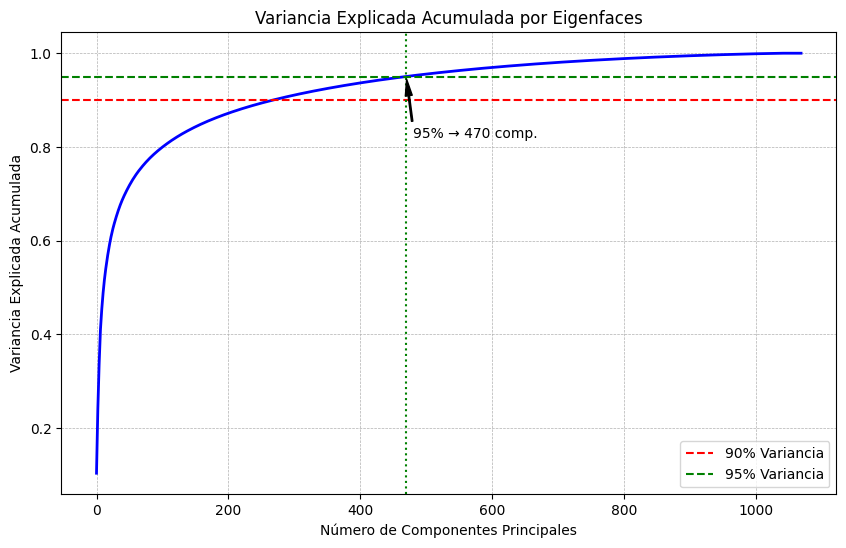

90% de variancia: 269 componentes
95% de variancia: 470 componentes

✅ Usando n_components = 269
PCA ajustado: 1070 fotos × 269 componentes


In [6]:
pca_full            = PCA().fit(X)
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(variancia_acumulada >= 0.90) + 1
n_95 = np.argmax(variancia_acumulada >= 0.95) + 1

plt.figure(figsize=(10, 6))
plt.plot(variancia_acumulada, linewidth=2, color='blue')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variancia')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variancia')
plt.axvline(x=n_95, color='g', linestyle=':')
plt.annotate(f'95% → {n_95} comp.',
             xy=(n_95, 0.95), xytext=(n_95+10, 0.82),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
plt.title('Variancia Explicada Acumulada por Eigenfaces')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Variancia Explicada Acumulada')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

print(f"90% de variancia: {n_90} componentes")
print(f"95% de variancia: {n_95} componentes")

n_components = n_90   # ← cambiado a 90%
print(f"\n✅ Usando n_components = {n_components}")

pca   = PCA(n_components=n_components, whiten=True).fit(X)
X_pca = pca.transform(X)

cara_promedio = pca.mean_.reshape(img_size, img_size)
eigenfaces    = pca.components_.reshape((n_components, img_size, img_size))

print(f"PCA ajustado: {X_pca.shape[0]} fotos × {X_pca.shape[1]} componentes")

## Fase 3: Visualización de Resultados Científicos

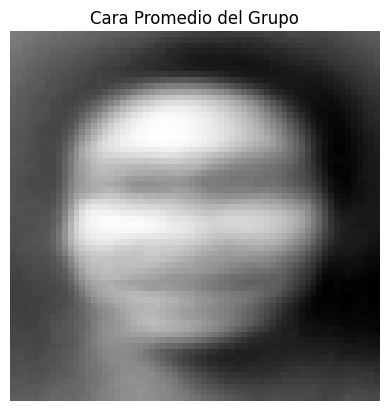

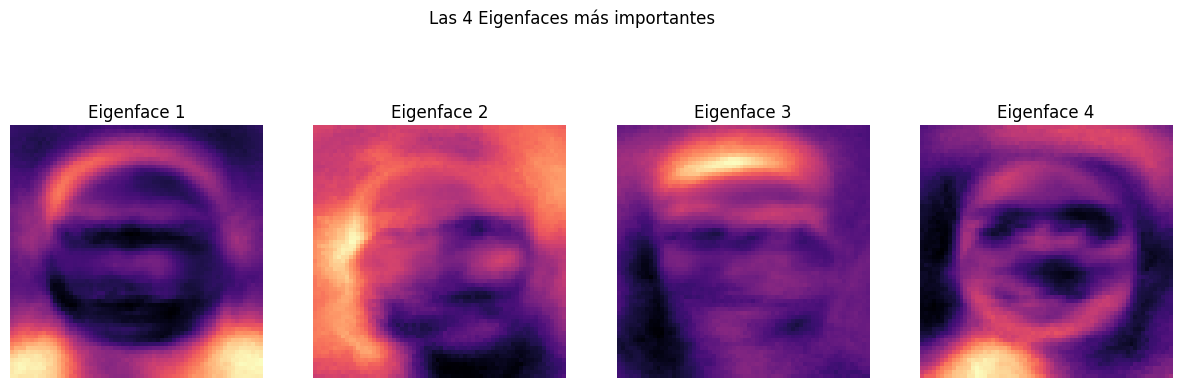

--- MÁXIMO PARECIDO ENTRE PERSONAS DISTINTAS ---
  juani_cacchione ↔️ lucia
  Similitud Coseno: 0.4655


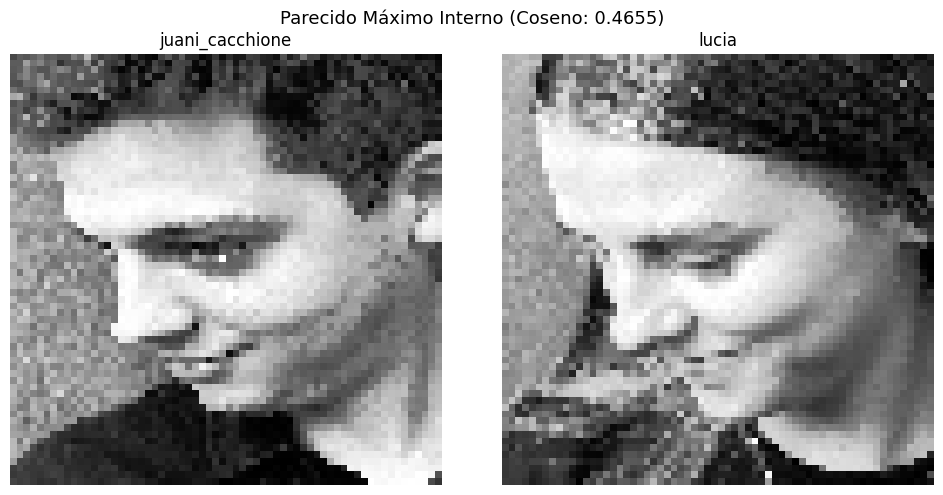

In [7]:
plt.imshow(cara_promedio, cmap='gray')
plt.title("Cara Promedio del Grupo")
plt.axis('off')
plt.show()

fig, ax = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    ax[i].imshow(eigenfaces[i], cmap='magma')
    ax[i].set_title(f"Eigenface {i+1}")
    ax[i].axis('off')
plt.suptitle("Las 4 Eigenfaces más importantes")
plt.show()

sim_matrix   = cosine_similarity(X_pca)
mask         = np.array([[all_labels[i] != all_labels[j]
                           for j in range(len(all_labels))]
                          for i in range(len(all_labels))])
filtered_sim = sim_matrix * mask
idx1, idx2   = np.unravel_index(np.argmax(filtered_sim), filtered_sim.shape)

print(f"--- MÁXIMO PARECIDO ENTRE PERSONAS DISTINTAS ---")
print(f"  {all_labels[idx1]} ↔️ {all_labels[idx2]}")
print(f"  Similitud Coseno: {filtered_sim[idx1, idx2]:.4f}")

img1 = cv2.imread(all_paths[idx1], cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(all_paths[idx2], cv2.IMREAD_GRAYSCALE)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img1, cmap='gray'); ax[0].set_title(all_labels[idx1]); ax[0].axis('off')
ax[1].imshow(img2, cmap='gray'); ax[1].set_title(all_labels[idx2]); ax[1].axis('off')
plt.suptitle(f"Parecido Máximo Interno (Coseno: {filtered_sim[idx1, idx2]:.4f})", fontsize=13)
plt.tight_layout()
plt.show()

## Fase 4: Entrenamiento con Backpropagation Multiclase

Los 427 componentes PCA son la entrada de la red neuronal.
Cada fila del DataFrame es una foto; la columna `y` tiene el nombre de la persona.

| pc0 | pc1 | ... | pc149 | y |
|-----|-----|-----|-------|---|
| 0.12 | -0.5 | ... | 0.03 | "martin" |
| 0.80 | 0.2 | ... | -0.1 | "persona_nueva" |

In [8]:
class perceptron_plot:
    def __init__(self, X, Y, delay):
        self.activo = X.shape[1] == 2
        self.delay  = delay
        if not self.activo: return
        self.X = X; self.Y = Y
        x1_min, x1_max = np.min(X[:, 0]), np.max(X[:, 0])
        x2_min, x2_max = np.min(X[:, 1]), np.max(X[:, 1])
        self.x1_min = x1_min - 0.1*(x1_max - x1_min)
        self.x1_max = x1_max + 0.1*(x1_max - x1_min)
        self.x2_min = x2_min - 0.1*(x2_max - x2_min)
        self.x2_max = x2_max + 0.1*(x2_max - x2_min)
        self.fig = plt.figure(figsize=(10, 8))
        self.ax  = self.fig.subplots()
        self.ax.set_xlim(self.x1_min, self.x1_max, auto=False)
        self.ax.set_ylim(self.x2_min, self.x2_max, auto=False)

    def graficarVarias(self, W, x0, epoch, error):
        if not self.activo: return
        display.clear_output(wait=True)
        plt.cla()
        self.ax.set_xlim(self.x1_min, self.x1_max)
        self.ax.set_ylim(self.x2_min, self.x2_max)
        plt.title('epoch ' + str(epoch) + '  MSE ' + "{0:.2E}".format(error))
        self.ax.scatter(self.X[:, 0], self.X[:, 1], c=self.Y, s=20)
        for i in range(len(x0)):
            vx2_min = -(W[i, 0]*self.x1_min + x0[i]) / W[i, 1]
            vx2_max = -(W[i, 0]*self.x1_max + x0[i]) / W[i, 1]
            self.ax.plot([self.x1_min, self.x1_max], [vx2_min, vx2_max],
                         linewidth=2, color='red', alpha=0.5)
        display.display(plt.gcf())
        time.sleep(self.delay)


def func_eval(fname, x):
    match fname:
        case "purelin": return x
        case "logsig":
            x = np.clip(x, -500, 500)
            return 1.0 / (1.0 + math.exp(-x))
        case "tansig":
            x = np.clip(x, -500, 500)
            return 2.0 / (1.0 + math.exp(-2.0*x)) - 1.0

def deriv_eval(fname, y):
    match fname:
        case "purelin": return 1.0
        case "logsig":  return y*(1.0 - y)
        case "tansig":  return 1.0 - y*y

func_eval_vec  = np.vectorize(func_eval)
deriv_eval_vec = np.vectorize(deriv_eval)


class multiperceptron(object):

    def _red_init(self, semilla):
        niveles = self.red['arq']['layers_qty']
        np.random.seed(semilla)
        for i in range(niveles):
            nivel = {
                'id': i, 'last': (i == (niveles-1)),
                'size': self.red["arq"]["layers_size"][i],
                'func': self.red["arq"]["layers_func"][i]
            }
            entrada_size = (self.red['arq']['input_size'] if i == 0
                            else self.red['arq']['layers_size'][i-1])
            salida_size  = nivel['size']
            nivel['W']    = np.random.uniform(-0.5, 0.5, [salida_size, entrada_size])
            nivel['w0']   = np.random.uniform(-0.5, 0.5, [salida_size, 1])
            nivel['W_m']  = np.zeros([salida_size, entrada_size])
            nivel['w0_m'] = np.zeros([salida_size, 1])
            self.red['layer'].append(nivel)

    def __init__(self):
        self.data = dict(); self.red = dict(); self.carpeta = ""

    def inicializar(self, df, campos, clase, hidden_layers_sizes, layers_func, semilla, carpeta):
        self.data['X'] = np.array(df.select(campos))
        X_mean         = self.data['X'].mean(axis=0)
        X_sd           = self.data['X'].std(axis=0)
        X_sd[X_sd == 0] = 1.0   # evitar división por cero
        self.data['X'] = (self.data['X'] - X_mean) / X_sd

        label               = df.select(clase)
        self.data['Ylabel'] = np.array(label).reshape(len(label))

        col_originales = df.columns
        self.data['Y'] = np.array(df.to_dummies(clase).drop(col_originales, strict=False))
        col_dummies    = sorted(list(set(df.to_dummies(clase).columns) - set(col_originales)))
        clases_orig    = reduce(lambda acc, x: acc + [x[(len(clase)+1):]], col_dummies, [])

        tamanos = hidden_layers_sizes + [self.data['Y'].shape[1]]
        self.red['arq'] = {
            'input_size'   : self.data['X'].shape[1],
            'input_mean'   : X_mean,
            'input_sd'     : X_sd,
            'output_values': clases_orig,
            'layers_qty'   : len(tamanos),
            'layers_size'  : tamanos,
            'layers_func'  : layers_func,
        }
        self.red['work']  = {'epoch': 0, 'MSE': float('inf'), 'train_error_rate': float('inf')}
        self.red['layer'] = []
        self._red_init(semilla)
        self.carpeta = carpeta
        os.makedirs(self.carpeta, exist_ok=True)
        with open(self.carpeta + "/data.pkl", 'wb') as f: pickle.dump(self.data, f)
        with open(self.carpeta + "/red.pkl",  'wb') as f: pickle.dump(self.red,  f)

    def entrenar(self, epoch_limit, MSE_umbral, learning_rate, lr_momento, save_frequency, retomar=True):
        if retomar:
            with open(self.carpeta + "/data.pkl", 'rb') as f: self.data = pickle.load(f)
            with open(self.carpeta + "/red.pkl",  'rb') as f: self.red  = pickle.load(f)

        epoch   = self.red['work']['epoch']
        MSE     = self.red['work']['MSE']
        niveles = self.red["arq"]["layers_qty"]
        Xfilas  = self.data['X'].shape[0]
        grafico = perceptron_plot(X=self.data['X'], Y=self.data['Ylabel'], delay=0.1)

        while (MSE > MSE_umbral) and (epoch < epoch_limit):
            epoch += 1
            for fila in range(Xfilas):
                x      = self.data['X'][fila:fila+1, :]
                clase  = self.data['Y'][fila:fila+1, :]
                entrada = x.T
                vsalida = [0] * niveles
                for i in range(niveles):
                    estimulos  = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
                    vsalida[i] = func_eval_vec(self.red['layer'][i]['func'], estimulos)
                    entrada    = vsalida[i]
                verror = [0] * (niveles + 1)
                verror[niveles] = clase.T - vsalida[niveles-1]
                i = niveles - 1
                verror[i] = verror[i+1] * deriv_eval_vec(self.red['layer'][i]['func'], vsalida[i])
                for i in reversed(range(niveles-1)):
                    verror[i] = (deriv_eval_vec(self.red['layer'][i]['func'], vsalida[i])
                                 * (self.red['layer'][i+1]['W'].T @ verror[i+1]))
                entrada = x.T
                for i in range(niveles):
                    self.red['layer'][i]['W_m']  = (learning_rate * (verror[i] @ entrada.T)
                                                    + lr_momento * self.red['layer'][i]['W_m'])
                    self.red['layer'][i]['w0_m'] = (learning_rate * verror[i]
                                                    + lr_momento * self.red['layer'][i]['w0_m'])
                    self.red['layer'][i]['W']  += self.red['layer'][i]['W_m']
                    self.red['layer'][i]['w0'] += self.red['layer'][i]['w0_m']
                    entrada = vsalida[i]

            entrada = self.data['X'].T
            for i in range(niveles):
                estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
                salida    = func_eval_vec(self.red['layer'][i]['func'], estimulos)
                entrada   = salida
            MSE = np.mean((self.data['Y'].T - salida)**2)

            if (epoch % save_frequency == 0) or (MSE <= MSE_umbral) or (epoch >= epoch_limit):
                grafico.graficarVarias(self.red['layer'][0]['W'],
                                       self.red['layer'][0]['w0'].T[0], epoch, MSE)
                self.red['work']['epoch'] = epoch
                self.red['work']['MSE']   = MSE
                prediccion = np.argmax(salida.T, axis=1)
                out        = np.array(self.red["arq"]['output_values'])
                self.red["work"]['train_error_rate'] = np.mean(self.data['Ylabel'] != out[prediccion])
                with open(self.carpeta + "/red.pkl", 'wb') as f: pickle.dump(self.red, f)
                print(f"  epoch {epoch:4d} | MSE {MSE:.5f} | error_rate {self.red['work']['train_error_rate']:.2%}")

        return (epoch, MSE, self.red['work']['train_error_rate'])

    def predecir_faces(self, X_new_pca, verbose=True):
        niveles = self.red['arq']['layers_qty']
        X_std   = (X_new_pca - self.red['arq']['input_mean']) / self.red['arq']['input_sd']
        entrada = X_std.T
        for i in range(niveles):
            estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
            salida    = func_eval_vec(self.red['layer'][i]['func'], estimulos)
            entrada   = salida
        pred_idx   = np.argmax(salida.T, axis=1)
        confianzas = np.max(salida.T, axis=1)
        out        = np.array(self.red['arq']['output_values'])
        if verbose:
            print("\n── Ranking de confianzas ──")
            scores = salida.T[0]
            for idx in np.argsort(scores)[::-1]:
                barra = "█" * int(abs(scores[idx]) * 20)
                print(f"  {out[idx]:20s} {scores[idx]:+.4f}  {barra}")
            print()
        return out[pred_idx], confianzas

    def cargar_modelo(self, carpeta):
        self.carpeta = carpeta
        with open(self.carpeta + "/red.pkl", 'rb') as f: self.red = pickle.load(f)
        return (self.red['work']['epoch'], self.red['work']['MSE'], self.red['work']['train_error_rate'])

In [11]:
def _recortar_cara_con_margen(img_arr, box):
    x, y, w, h = box
    margen = int(0.2 * min(w, h))
    x1 = max(0, x - margen)
    y1 = max(0, y - margen)
    x2 = min(img_arr.shape[1], x + w + margen)
    y2 = min(img_arr.shape[0], y + h + margen)
    return img_arr[y1:y2, x1:x2]

def identificar_foto_nueva(ruta_foto, modelo_bp, pca_modelo, detector_mtcnn,
                            umbral_confianza=0.60, verbose=True):
    img_bgr = cv2.imread(ruta_foto)
    if img_bgr is None:
        print("Error: no se pudo leer la imagen."); return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    res     = detector_mtcnn.detect_faces(img_rgb)
    if not res:
        print("No se detectó ningún rostro."); return None
    face         = _recortar_cara_con_margen(img_rgb, res[0]['box'])
    face_gray    = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)
    face_resized = cv2.resize(face_gray, (img_size, img_size)).flatten() / 255.0
    face_pca            = pca_modelo.transform(face_resized.reshape(1, -1))
    nombres, confianzas = modelo_bp.predecir_faces(face_pca, verbose=verbose)
    nombre    = nombres[0]
    confianza = confianzas[0]
    resultado = (f"DESCONOCIDO (mejor: {nombre}, {confianza:.2%})"
                 if confianza < umbral_confianza
                 else f"{nombre.upper()} — Confianza: {confianza:.2%}")
    plt.imshow(face_gray, cmap='gray')
    plt.title(resultado); plt.axis('off'); plt.show()
    print(f"→ {resultado}")
    return nombre, confianza

In [13]:
cols_pca = [f"pc{i}" for i in range(n_components)]
df_caras = pl.DataFrame(X_pca, schema=cols_pca).with_columns(
    pl.Series("y", all_labels)
)
print(f"DataFrame: {df_caras.shape[0]} filas × {df_caras.shape[1]} columnas")

carpeta_modelo      = ruta_modelos + '/backprop_caras'
hidden_layers_sizes = [128, 64]
layers_func         = ['tansig', 'tansig', 'purelin']  # purelin en salida = más estable

mp = multiperceptron()
mp.inicializar(
    df                  = df_caras,
    campos              = cols_pca,
    clase               = "y",
    hidden_layers_sizes = hidden_layers_sizes,
    layers_func         = layers_func,
    semilla             = 42,
    carpeta             = carpeta_modelo
)

n_clases = len(np.unique(all_labels))
print("Arquitectura:")
print(f"  Entrada  : {n_components} neuronas")
for i, (sz, fn) in enumerate(zip(hidden_layers_sizes, layers_func[:-1])):
    print(f"  Oculta {i+1} : {sz} neuronas ({fn})")
print(f"  Salida   : {n_clases} neuronas ({layers_func[-1]})")

(epoch, MSE, train_error_rate) = mp.entrenar(
    epoch_limit    = 3000,
    MSE_umbral     = 0.005,
    learning_rate  = 0.005,
    lr_momento     = 0.1,
    save_frequency = 100,
    retomar        = False
)
print(f"\n✅ Epochs: {epoch}  |  MSE: {MSE:.5f}  |  Error rate: {train_error_rate:.2%}")

DataFrame: 1070 filas × 270 columnas
Arquitectura:
  Entrada  : 269 neuronas
  Oculta 1 : 128 neuronas (tansig)
  Oculta 2 : 64 neuronas (tansig)
  Salida   : 14 neuronas (purelin)
  epoch  100 | MSE 0.02816 | error_rate 8.22%
  epoch  200 | MSE 0.01111 | error_rate 0.09%
  epoch  269 | MSE 0.00496 | error_rate 0.00%

✅ Epochs: 269  |  MSE: 0.00496  |  Error rate: 0.00%


In [14]:
os.makedirs(ruta_modelos, exist_ok=True)
joblib.dump(pca, ruta_modelos + '/pca_caras.pkl')
print(f"✅ PCA guardado en {ruta_modelos}/pca_caras.pkl")
print(f"✅ Red guardada en {carpeta_modelo}/red.pkl")

✅ PCA guardado en /content/drive/MyDrive/02 - 2026 - Data Mining Avanzado/Modelos/pca_caras.pkl
✅ Red guardada en /content/drive/MyDrive/02 - 2026 - Data Mining Avanzado/Modelos/backprop_caras/red.pkl


In [15]:
def identificar_foto_nueva(ruta_foto, modelo_bp, pca_modelo, detector_mtcnn,
                            umbral_confianza=0.60, verbose=True):
    # Soporte para HEIC y formatos normales
    try:
        img_pil = Image.open(ruta_foto).convert('RGB')
        img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    except Exception as e:
        print(f"Error: no se pudo leer la imagen: {e}"); return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    res     = detector_mtcnn.detect_faces(img_rgb)
    if not res:
        print("No se detectó ningún rostro."); return None
    face         = _recortar_cara_con_margen(img_rgb, res[0]['box'])
    face_gray    = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)
    face_resized = cv2.resize(face_gray, (img_size, img_size)).flatten() / 255.0
    face_pca            = pca_modelo.transform(face_resized.reshape(1, -1))
    nombres, confianzas = modelo_bp.predecir_faces(face_pca, verbose=verbose)
    nombre    = nombres[0]
    confianza = confianzas[0]
    resultado = (f"DESCONOCIDO (mejor: {nombre}, {confianza:.2%})"
                 if confianza < umbral_confianza
                 else f"{nombre.upper()} — Confianza: {confianza:.2%}")
    plt.imshow(face_gray, cmap='gray')
    plt.title(resultado); plt.axis('off'); plt.show()
    print(f"→ {resultado}")
    return nombre, confianza


── Ranking de confianzas ──
  migue                +0.5689  ███████████
  judi                 +0.5345  ██████████
  juani_cacchione      +0.3710  ███████
  guille               +0.2875  █████
  mariangeles          +0.2166  ████
  belen                +0.1806  ███
  ignacio_paberolis    -0.0297  
  tomas_delbo          -0.0420  
  martin               -0.0436  
  millie               -0.0484  
  agus                 -0.0989  █
  mati_villanueva      -0.1738  ███
  fede                 -0.3007  ██████
  lucia                -0.4221  ████████



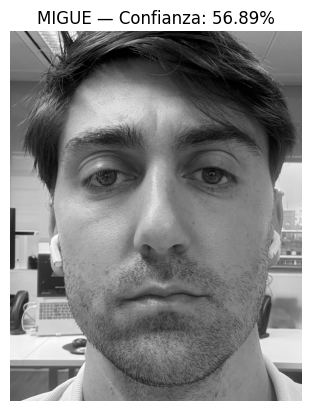

→ MIGUE — Confianza: 56.89%


(np.str_('migue'), np.float64(0.5689304135441021))

In [22]:
identificar_foto_nueva(
    ruta_foto      = '/content/drive/MyDrive/02 - 2026 - Data Mining Avanzado/fotos_externas/migue.HEIC',
    modelo_bp      = mp,
    pca_modelo     = pca,
    detector_mtcnn = detector,
    umbral_confianza = 0.50
)


── Ranking de confianzas ──
  martin               +0.6754  █████████████
  judi                 +0.5504  ███████████
  tomas_delbo          +0.4448  ████████
  juani_cacchione      +0.3974  ███████
  fede                 +0.1435  ██
  ignacio_paberolis    +0.1179  ██
  lucia                +0.0869  █
  guille               +0.0706  █
  mariangeles          +0.0692  █
  mati_villanueva      +0.0346  
  migue                -0.0303  
  millie               -0.2071  ████
  belen                -0.3297  ██████
  agus                 -1.0235  ████████████████████



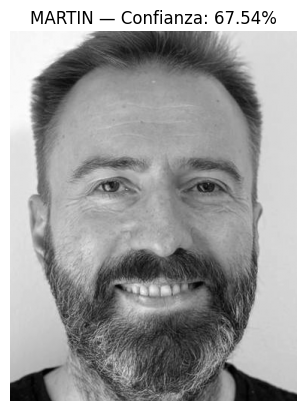

→ MARTIN — Confianza: 67.54%


(np.str_('martin'), np.float64(0.6754447088988393))

In [23]:
identificar_foto_nueva(
    ruta_foto      = '/content/drive/MyDrive/02 - 2026 - Data Mining Avanzado/fotos_externas/mc.jpeg',
    modelo_bp      = mp,
    pca_modelo     = pca,
    detector_mtcnn = detector,
    umbral_confianza = 0.50
)


── Ranking de confianzas ──
  ignacio_paberolis    +0.5102  ██████████
  martin               +0.4777  █████████
  juani_cacchione      +0.3932  ███████
  lucia                +0.3330  ██████
  tomas_delbo          +0.2026  ████
  millie               +0.1655  ███
  mati_villanueva      +0.1053  ██
  guille               +0.0889  █
  belen                -0.0760  █
  fede                 -0.1149  ██
  mariangeles          -0.1263  ██
  agus                 -0.1802  ███
  migue                -0.2985  █████
  judi                 -0.4804  █████████



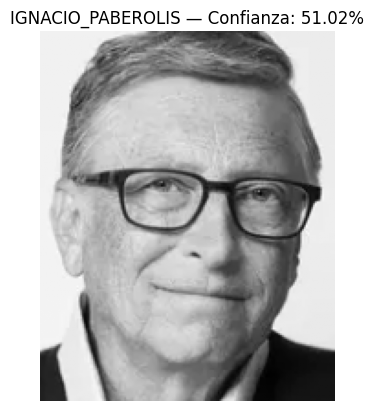

→ IGNACIO_PABEROLIS — Confianza: 51.02%


(np.str_('ignacio_paberolis'), np.float64(0.5101620207094174))

In [24]:
identificar_foto_nueva(
    ruta_foto      = '/content/drive/MyDrive/02 - 2026 - Data Mining Avanzado/fotos_externas/bg.png',
    modelo_bp      = mp,
    pca_modelo     = pca,
    detector_mtcnn = detector,
    umbral_confianza = 0.50
)

In [18]:
os.makedirs(ruta_modelos, exist_ok=True)
joblib.dump(pca, ruta_modelos + '/pca_caras.pkl')
print(f"✅ PCA guardado")
print(f"✅ Red guardada")

✅ PCA guardado
✅ Red guardada


## Fase 5: Agregar una Persona Nueva al Dataset

Si apareció una persona nueva y querés que el modelo la reconozca:

1. Creá una subcarpeta con su nombre en la carpeta de Caras originales:
   `Caras/nombre_apellido/foto1.jpg, foto2.jpg, ...`
   (mínimo recomendado: 10 fotos con variedad de ángulos y luz)
2. Ejecutá la siguiente celda para procesar solo las fotos nuevas.
3. Re-ejecutá las celdas de **Fase 2 en adelante** para reentrenar PCA y Backpropagation.

> ⚠️ El PCA debe reajustarse desde cero cuando se agrega alguien nuevo,
> porque cambia el espacio de varianza de todo el dataset.

In [ ]:
def procesar_persona_nueva(nombre, origen_base, destino_base):
    carpeta_fotos   = os.path.join(origen_base, nombre)
    carpeta_destino = os.path.join(destino_base, nombre)
    if not os.path.exists(carpeta_fotos):
        print(f"⚠ No existe: {carpeta_fotos}")
        return False
    os.makedirs(carpeta_destino, exist_ok=True)
    procesadas = 0; errores = 0
    for img_name in tqdm(os.listdir(carpeta_fotos), desc=f"Procesando {nombre}"):
        img_path = os.path.join(carpeta_fotos, img_name)
        if not os.path.isfile(img_path): continue
        try:
            img     = Image.open(img_path).convert('RGB')
            img_arr = np.array(img)
            res     = detector.detect_faces(img_arr)
            if res:
                face         = _recortar_cara_con_margen(img_arr, res[0]['box'])
                face_gray    = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)
                face_resized = cv2.resize(face_gray, (img_size, img_size))
                cv2.imwrite(os.path.join(carpeta_destino, img_name + ".jpg"), face_resized)
                procesadas += 1
            else:
                print(f"  ⚠ Sin cara: {img_name}"); errores += 1
        except Exception as e:
            print(f"  ⚠ Error {img_name}: {e}"); errores += 1
    print(f"\n✅ {nombre}: {procesadas} guardadas, {errores} sin detección.")
    if procesadas == 0:
        print("  ❌ Revisá que las fotos muestren la cara claramente.")
        return False
    print("  → Re-ejecutá Fases 2 en adelante para reentrenar.")
    return True

nombre_nuevo = 'mati_villanueva'
procesar_persona_nueva(nombre_nuevo, fotos_originales, fotos_finales)

Procesando mati_villanueva:   2%|▏         | 2/92 [01:19<54:34, 36.38s/it]  

  ⚠ Sin cara: matias_villanueva (68).jpeg


Procesando mati_villanueva:  14%|█▍        | 13/92 [05:54<28:02, 21.30s/it]

  ⚠ Sin cara: matias_villanueva (79).jpeg


Procesando mati_villanueva:  15%|█▌        | 14/92 [06:18<28:45, 22.12s/it]

## Fase 6: Predicción en Fotos Nuevas

La función `identificar_foto_nueva()` recibe como parámetros el modelo, el PCA y el detector.
Así funciona tanto en la **sesión de entrenamiento** como cargando desde Drive en una **sesión nueva**.

In [ ]:
def identificar_foto_nueva(ruta_foto, modelo_bp, pca_modelo, detector_mtcnn,
                            umbral_confianza=0.60, verbose=True):
    img_bgr = cv2.imread(ruta_foto)
    if img_bgr is None:
        print("Error: no se pudo leer la imagen."); return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    res     = detector_mtcnn.detect_faces(img_rgb)
    if not res:
        print("No se detectó ningún rostro."); return None

    face         = _recortar_cara_con_margen(img_rgb, res[0]['box'])
    face_gray    = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)
    face_resized = cv2.resize(face_gray, (img_size, img_size)).flatten() / 255.0

    face_pca            = pca_modelo.transform(face_resized.reshape(1, -1))
    nombres, confianzas = modelo_bp.predecir_faces(face_pca, verbose=verbose)
    nombre    = nombres[0]
    confianza = confianzas[0]

    resultado = (f"DESCONOCIDO (mejor: {nombre}, {confianza:.2%})"
                 if confianza < umbral_confianza
                 else f"{nombre.upper()} — Confianza: {confianza:.2%}")

    plt.imshow(face_gray, cmap='gray')
    plt.title(resultado); plt.axis('off'); plt.show()
    print(f"→ {resultado}")
    return nombre, confianza


identificar_foto_nueva(
    ruta_foto      = '/content/drive/MyDrive/Austral - Maestría Ciencia de Datos/02 - 2026 - Data Mining Avanzado/fotos_externas/bg.jpeg',
    modelo_bp      = mp,
    pca_modelo     = pca,
    detector_mtcnn = detector
)

NameError: name 'mp' is not defined

In [ ]:
print(mp)

NameError: name 'mp' is not defined

In [ ]:
# Ejecutar esto en una sesión nueva en lugar de reentrenar

# pca_cargado = joblib.load(ruta_modelos + '/pca_caras.pkl')
# mp_cargado  = multiperceptron()
# mp_cargado.cargar_modelo(ruta_modelos + '/backprop_caras')
# detector_nuevo = MTCNN()

# identificar_foto_nueva(
#     ruta_foto      = '/content/drive/MyDrive/.../foto.jpg',
#     modelo_bp      = mp_cargado,
#     pca_modelo     = pca_cargado,
#     detector_mtcnn = detector_nuevo
# )

In [ ]:
def _corregir_rotacion(img_pil):
    """
    Intenta detectar una cara en la imagen original.
    Si no encuentra, prueba rotando en pasos de 90°.
    Si tampoco, prueba con rotaciones finas (±15°, ±30°, ±45°).
    Devuelve (img_arr, resultado_deteccion) con la mejor orientación encontrada.
    """
    img_arr = np.array(img_pil)
    res = detector.detect_faces(img_arr)
    if res:
        return img_arr, res  # ya estaba bien

    # Rotaciones de 90° (costo casi cero)
    for angulo in [90, 180, 270]:
        rotada = img_pil.rotate(angulo, expand=True)
        arr    = np.array(rotada)
        res    = detector.detect_faces(arr)
        if res:
            return arr, res

    # Rotaciones finas si las de 90° no alcanzaron
    for angulo in [-45, 45, -30, 30, -15, 15]:
        rotada = img_pil.rotate(angulo, expand=True, fillcolor=(128, 128, 128))
        arr    = np.array(rotada)
        res    = detector.detect_faces(arr)
        if res:
            return arr, res

    # No se encontró cara en ninguna orientación
    return img_arr, []


def _recortar_cara_con_margen(img_arr, box):
    """Recorte con margen del 20% — función compartida por todo el pipeline."""
    x, y, w, h = box
    margen = int(0.2 * min(w, h))
    x1 = max(0, x - margen)
    y1 = max(0, y - margen)
    x2 = min(img_arr.shape[1], x + w + margen)
    y2 = min(img_arr.shape[0], y + h + margen)
    return img_arr[y1:y2, x1:x2]


def procesar_dataset(origen, destino):
    os.makedirs(destino, exist_ok=True)
    for person in os.listdir(origen):
        path_p = os.path.join(origen, person)
        if not os.path.isdir(path_p) or person.startswith('.'): continue
        save_p = os.path.join(destino, person)
        os.makedirs(save_p, exist_ok=True)
        for img_name in tqdm(os.listdir(path_p), desc=f"Procesando {person}"):
            try:
                img = Image.open(os.path.join(path_p, img_name)).convert('RGB')

                if res:
                    face         = _recortar_cara_con_margen(img_arr, res[0]['box'])
                    face_gray    = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)
                    face_resized = cv2.resize(face_gray, (img_size, img_size))
                    cv2.imwrite(os.path.join(save_p, img_name + ".jpg"), face_resized)
                else:
                    print(f"  ⚠ Sin cara en ninguna rotación: {img_name}")
            except Exception as e:
                print(f"  ⚠ Saltando {img_name}: {e}")

#procesar_dataset(fotos_originales, fotos_finales)